# 1 Import libraries 

In [1]:
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability
import atlite
import rasterio as rio
from rasterio.plot import show
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import country_converter as coco
import atlite
from pyproj import Proj, transform
import netCDF4 as nc
from urllib.request import urlretrieve
import warnings
warnings.filterwarnings("ignore")
from vresutils.graph import voronoi_partition_pts
import cartopy.crs as ccrs
import pypsa
import random
from pypsa.plot import add_legend_patches
import copy
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

# 2 Land Eligibility

## 2.1 Import data

In [2]:
fn_country = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fgadm&files=gadm_410-levels-ADM_1-ESP.gpkg"
country = gpd.read_file(fn_country)
country = country[~country['NAME_1'].isin(['Islas Baleares', 'Islas Canarias'])]

In [3]:
eez_path = r'C:\Users\SanketMane\OneDrive - HIF Global SpA\Documents\MS\DSESM\Group Assignment\1 Naval Regions\World_EEZ_v11_20191118_gpkg\eez_v11.gpkg'
ocean = gpd.read_file(eez_path)
ocean = ocean[ocean.GEONAME == "Spanish Exclusive Economic Zone"]

## 2.2 Splitting Spain into 5 regions

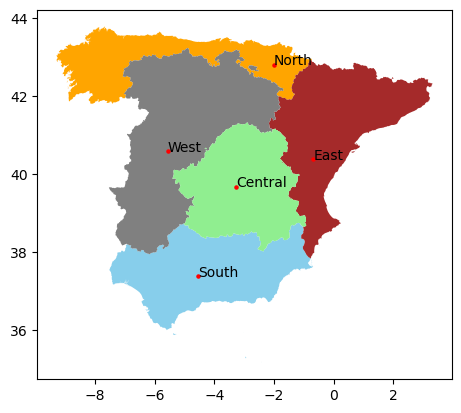

In [4]:
regions = country.copy()
regions["regions"]= [2,3,1,5,4,3,2,5,1,3,4,1,4,1,1,2]
regions = regions.dissolve(by="regions") # Dissolving it by assigned regions
points = regions.representative_point() # Finding representative points
region_names = ['North','South','East','West','Central']
regions['Short_Name'] = region_names
regions.index = regions.Short_Name
provinces = regions
regions = regions[['geometry']]

colors = ( "orange", "skyblue", "brown", "grey", "lightgreen") # Assigning colours to each region
fig, ax = plt.subplots()
regions.reset_index().plot(ax=ax, column='Short_Name',color=colors)
points.plot(ax=ax, color='red', markersize=5);

for i, name in enumerate(region_names):
    ax.annotate(name, (points.x[i+1], points.y[i+1]))

## 2.3 Splitting Spanish EEZ into 5 regions

In [5]:
eez_regions = country.copy()
eez_regions["eez_regions"] = [2,3,1,2,1,3,2,1,1,3,1,1,1,1,1,2]
eez_regions = eez_regions.dissolve(by="eez_regions") # Dissolving it by assigned regions
eez_points = eez_regions.representative_point() # Finding representative points
eez_region_names = ['North','South','East']
region_names_df = gpd.GeoDataFrame({
    'EEZ_Short_Name': eez_region_names,
    'geometry': eez_points.values
})

# Set the index of the DataFrame
region_names_df.set_index('EEZ_Short_Name', inplace=True)

# Keep only the geometry column
region_names_df = region_names_df[['geometry']]

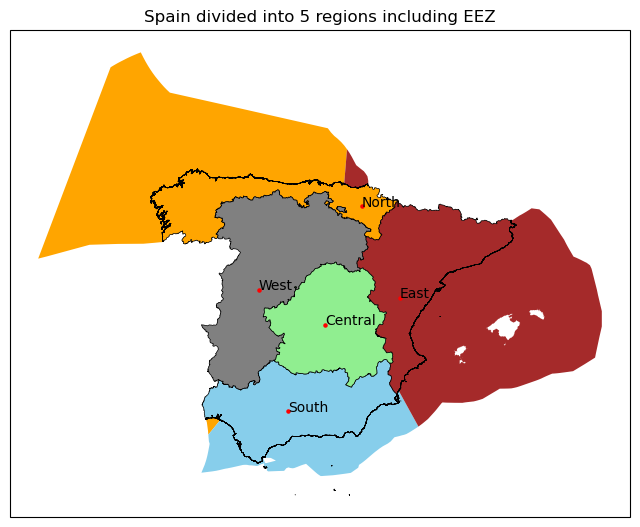

In [6]:
eez_shape = ocean.geometry.iloc[0]

eez_split = gpd.GeoDataFrame(
{        "name": eez_points.index,
        "geometry": voronoi_partition_pts(list(zip(eez_points.x, eez_points.y)), eez_shape) }
).set_index('name')
eez_split = eez_split.loc[eez_split.area > 1e-2]
eez_region_names = ['North','South','East']
eez_split['EEZ_Short_Name'] = eez_region_names
eez_split.index = eez_split.EEZ_Short_Name
eez_split = eez_split.drop(columns=['EEZ_Short_Name'])
ocean_region = eez_split.copy()

fig = plt.figure(figsize=(8,8))
eez_colors = ( "orange", "skyblue", "brown")
ax = plt.axes(projection=ccrs.EqualEarth())
ocean_region.reset_index().plot(ax=ax, column='EEZ_Short_Name', color = eez_colors)
regions.reset_index().plot(ax=ax, linewidth=0.5, edgecolor='k', column='Short_Name', color = colors)
points.plot(ax=ax, color='red', markersize=5);
plt.title('Spain divided into 5 regions including EEZ')

for i, txt in enumerate(region_names):
    ax.annotate(txt, (points.x[i+1], points.y[i+1]))

## 2.4 Eligible land

In [7]:
spain = country.dissolve(by='COUNTRY').to_crs(crs=3035)
spain_area = spain['geometry'].item()

spanish_ocean = ocean[ocean.GEONAME == "Spanish Exclusive Economic Zone"].to_crs(crs=3035)
spanish_ocean = spanish_ocean['geometry'].item()

### 2.4.1 Eligible land inland territories for Onshore Wind

In [8]:
onshore_excluder = ExclusionContainer(crs=3035, res=300)

onshore_shape = regions.to_crs(onshore_excluder.crs).geometry

#10km distance to airports
airports_url = "./data/ne_10m_airports.gpkg"
onshore_excluder.add_geometry(airports_url, buffer = 10000)

#300m distance to major roads
roads_url = "./data/ne_10m_roads.gpkg"
onshore_excluder.add_geometry(roads_url, buffer = 300)

# max_elev. 2000m, 1000m from built up areas and only suitable land cover classes (copernicus-glc)
land_url = "./data/6 Copernicus/PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-ES.tif"
onshore_excluder.add_raster(land_url, codes=lambda x: x>2000, crs=4326) #Exclude elevation over 2000m
onshore_excluder.add_raster(land_url, codes=[50], buffer=1000, crs=4326) #1000m to built-up areas
onshore_excluder.add_raster(land_url, codes=[20,30,40,60], crs=4326, invert=True)

# No natural protection areas (wdpa)
natural_url = "./data/2 WDPA/WDPA_Oct2022_Public_shp-ESP.tif"
onshore_excluder.add_raster(natural_url, crs=3035)

In [9]:
ocean_excluder = ExclusionContainer(crs=3035, res=300)
ocean_region = ocean_region.set_crs(4326)
ocean_shape = ocean_region.to_crs(ocean_excluder.crs).geometry

#within EEZ
eez_boundary = "./data/1 Naval Regions/World_EEZ_v11_20191118_gpkg/eez_boundaries_v11.gpkg"
ocean_excluder.add_geometry(eez_boundary)

# Upto water depth of 50m(gebco)
depth_distance = "./data/5 gebco/GEBCO_2014_2D-ES.nc"
ocean_excluder.add_raster(depth_distance, codes=lambda x: x<(-50), crs=4326)

# 10km minimum distance to shore 
ocean_excluder.add_geometry(spain, buffer = 10000)

# No natural protection areas (wdpa)
natural_url = "./data/2 WDPA/WDPA_Oct2022_Public_shp-ESP.tif"
ocean_excluder.add_raster(natural_url, crs=3035)

### 2.4.2 Eligible EEZ for Offshore Wind

### 2.4.3 Eligible inland territories for Solar

In [10]:
solar_excluder = ExclusionContainer(crs=3035, res=300)

solar_shape = regions.to_crs(solar_excluder.crs).geometry

# only suitable land cover classes (copernicus-glc)
land_url = "./data/6 Copernicus/PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-ES.tif"
solar_excluder.add_raster(land_url, codes=[20,30,40,60], crs=4326, invert=True)

# No natural protection areas (wdpa)
natural_url = "./data/2 WDPA/WDPA_Oct2022_Public_shp-ESP.tif"
solar_excluder.add_raster(natural_url, crs=3035)

## 2.5 Funtions for plotting and Eligible area calculation

In [11]:
def plot_area(masked, transform, shape):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax = show(masked, transform=transform, cmap="Greens", vmin=0, ax=ax)
    shape.plot(ax=ax, edgecolor="k", color="None", linewidth=1)

In [12]:
def eligible_area_function(masked, excluder,country):
    country_area = country.area/10**6
    cell_area = excluder.res**2/10**6
    eligible_cells = masked.sum()
    eligible_area = (cell_area * eligible_cells)
    available_percentage= (eligible_area / country_area)*100
    return available_percentage, eligible_area

In [13]:
def area_calculation(land_shape, excluder, offshore= False):
    area_percentage = []
    available_area = []
    x = 0
    y = 1

    for i in land_shape.index:
        masked, transform = shape_availability(land_shape[x:y], excluder)
        arp, ar = eligible_area_function(masked, excluder, land_shape[x:y])
        area_percentage.append(arp.item())
        available_area.append(ar)
        x = x+1
        y = y+1

    available_area = [i for i in available_area]
    df = pd.DataFrame()

    if offshore:
        df['Short_Name'] = eez_region_names
    else:
        df['Short_Name'] = region_names
        
    df['Area km2'] = available_area
    df['Area_Percentage'] = area_percentage
    df = df.set_index('Short_Name')
    df['Cap per region'] = df['Area km2'] * 3 # MW/km2

    return df

In [14]:
df_solar_cap = area_calculation(solar_shape, solar_excluder)

In [15]:
df_onwind_cap = area_calculation(onshore_shape, onshore_excluder)

In [16]:
df_offwind_cap = area_calculation(ocean_shape, ocean_excluder, offshore=True)

## 2.6 Plotting and area calculation

### 2.6.1 Plotting and area calculation for Onshore Wind

For Onshore, 153944.2 km2 is available, which is 31.19% of Spanish Land


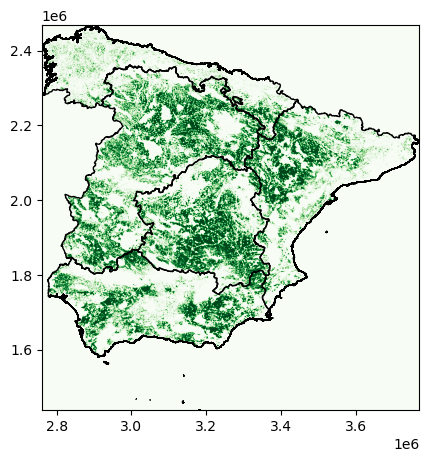

In [17]:
onshore_masked, onshore_transform = shape_availability(onshore_shape, onshore_excluder)
available_percentage, eligible_area = eligible_area_function(onshore_masked,onshore_excluder,spain_area)
print(f'For Onshore, {eligible_area:0.1f} km2 is available, which is {available_percentage:0.2f}% of Spanish Land')
plot_area(onshore_masked, onshore_transform, onshore_shape)

### 2.6.2 Plotting and area calculation for Offshore Wind

For Offshore, 1582.5 km2 is available, which is 0.28% of Spanish Land


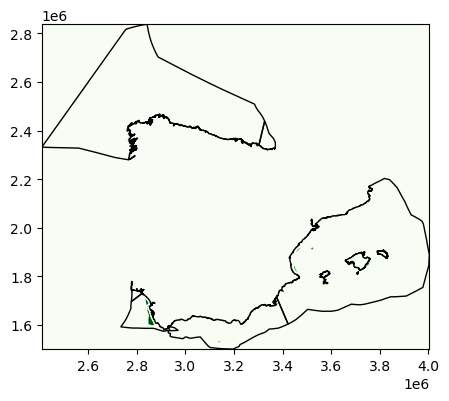

In [18]:
offshore_masked, offshore_transform = shape_availability(ocean_shape, ocean_excluder)
available_percentage, eligible_area = eligible_area_function(offshore_masked, ocean_excluder, spanish_ocean)
print(f'For Offshore, {eligible_area:0.1f} km2 is available, which is {available_percentage:0.2f}% of Spanish Land')
plot_area(offshore_masked, offshore_transform, ocean_shape)

### 2.6.2 Plotting and area calculation for Solar

For Solar, 209014.7 km2 is available, which is 42.35% of Spanish Land


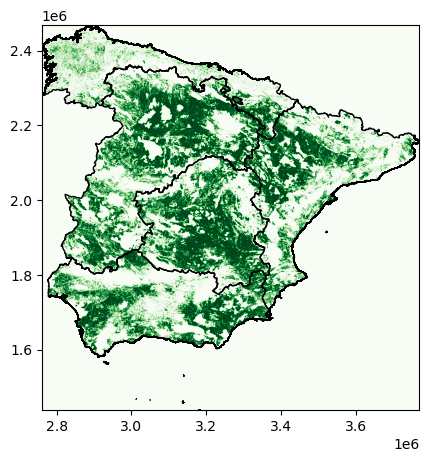

In [19]:
solar_masked, solar_transform = shape_availability(solar_shape, solar_excluder)
available_percentage, eligible_area = eligible_area_function(solar_masked, solar_excluder, spain_area)
print(f'For Solar, {eligible_area:0.1f} km2 is available, which is {available_percentage:0.2f}% of Spanish Land')
plot_area(solar_masked, solar_transform, solar_shape)

# 3 ERA5 inland weather data collection

## 3.1 Spain's region cutout

In [20]:
minx, miny, maxx, maxy = regions.total_bounds
buffer = 0.25
region_cutout = atlite.Cutout(
    path="europe-2013-era5.nc",
    module="era5",
    x=slice(minx - buffer, maxx + buffer),
    y=slice(miny - buffer, maxy + buffer),
    time="2013",
)

## 3.2 Spain's ocean cutout

In [21]:
ocean_minx, ocean_miny, ocean_maxx, ocean_maxy = ocean_region.total_bounds
buffer = 0.25

ocean_cutout = atlite.Cutout(
   path="europe-2013-era5.nc",
   module="era5",
   x=slice(ocean_minx-buffer, ocean_maxx+buffer),
   y=slice(ocean_miny-buffer, ocean_maxy+buffer),
   time="2013",
)

## 3.3 Availability Matrix

In [22]:
onshore_AM = region_cutout.availabilitymatrix(regions, onshore_excluder)
offshore_AM = ocean_cutout.availabilitymatrix(ocean_region, ocean_excluder)
solar_AM = region_cutout.availabilitymatrix(regions, solar_excluder)

Compute availability matrix: 100%|███████████████████████████████████████████████| 5/5 [00:13<00:00,  2.74s/ gridcells]


## 3.4 Deployment and profiles creation

In [23]:
#deployment density per square km region (MW/km^2)
cap_per_sqkm = 3

### 3.4.1 Onshore Wind Profile

In [24]:
onshore_area = region_cutout.grid.set_index(["y", "x"]).to_crs(3035).area / 1e6
onshore_area = xr.DataArray(onshore_area, dims=("spatial"))

onshore_capacity_matrix = onshore_AM.stack(spatial=["y", "x"]) * onshore_area * cap_per_sqkm

onshore_wind = region_cutout.wind(
    atlite.windturbines.Vestas_V112_3MW,
    matrix=onshore_capacity_matrix,
    index=regions.index,
    per_unit=True,
)
onshore_wind_df = onshore_wind.to_pandas()

[########################################] | 100% Completed | 235.88 s


### 3.4.2 Offshore Wind Profile

In [25]:
offshore_area = ocean_cutout.grid.set_index(["y", "x"]).to_crs(3035).area / 1e6
offshore_area = xr.DataArray(onshore_area, dims=("spatial"))

offshore_capacity_matrix = offshore_AM.stack(spatial=["y", "x"]) * offshore_area * cap_per_sqkm

offshore_wind = ocean_cutout.wind(
    atlite.windturbines.NREL_ReferenceTurbine_5MW_offshore,
    matrix=offshore_capacity_matrix,
    index=ocean_region.index,
    per_unit=True,
)
offshore_wind_df = offshore_wind.to_pandas()

[########################################] | 100% Completed | 233.51 s


### 3.4.3 Solar PV Profile

In [26]:
solar_area = region_cutout.grid.set_index(["y", "x"]).to_crs(3035).area / 1e6
solar_area = xr.DataArray(solar_area, dims=("spatial"))

solar_capacity_matrix = solar_AM.stack(spatial=["y", "x"]) * solar_area * cap_per_sqkm

solar_pv = region_cutout.pv(
    panel=atlite.solarpanels.CdTe,
    matrix=solar_capacity_matrix,
    orientation='latitude_optimal',
    index=regions.index,
    per_unit=True,
)
solar_pv_df = solar_pv.to_pandas()

[########################################] | 100% Completed | 13m 22s


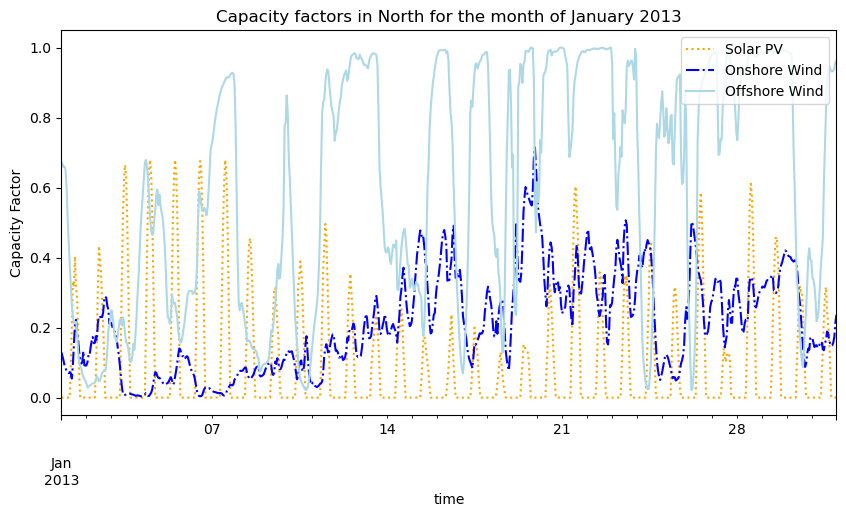

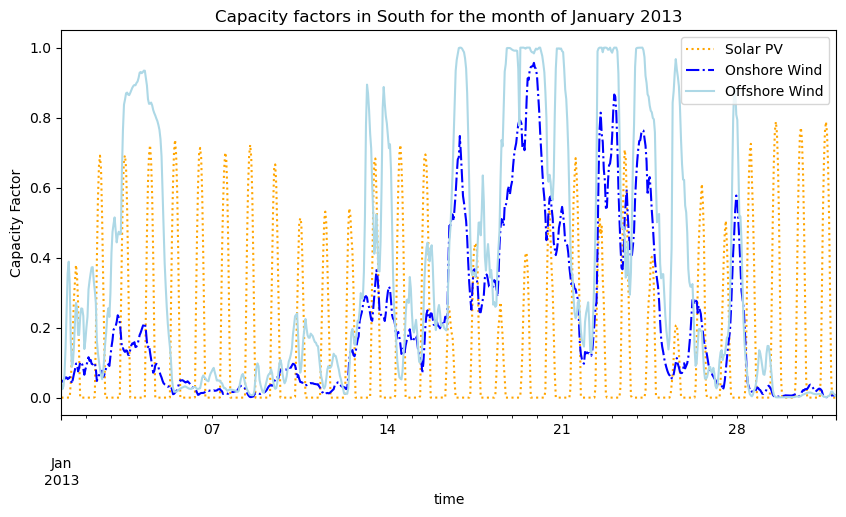

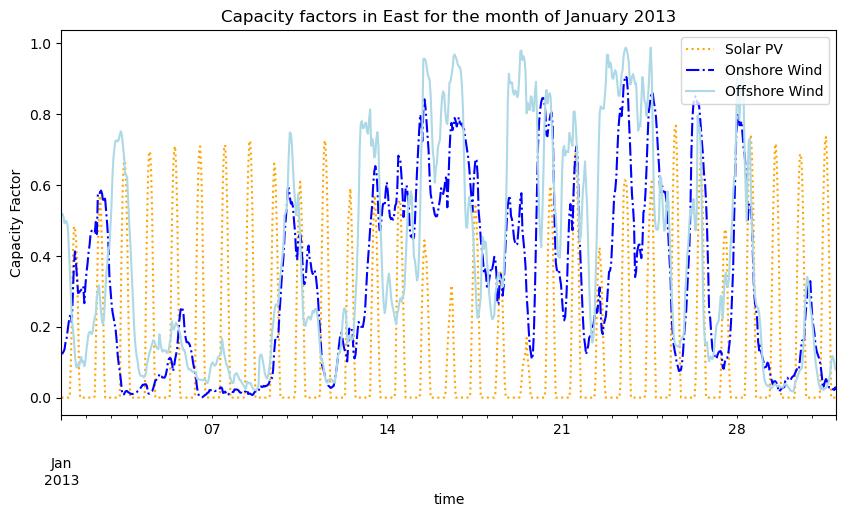

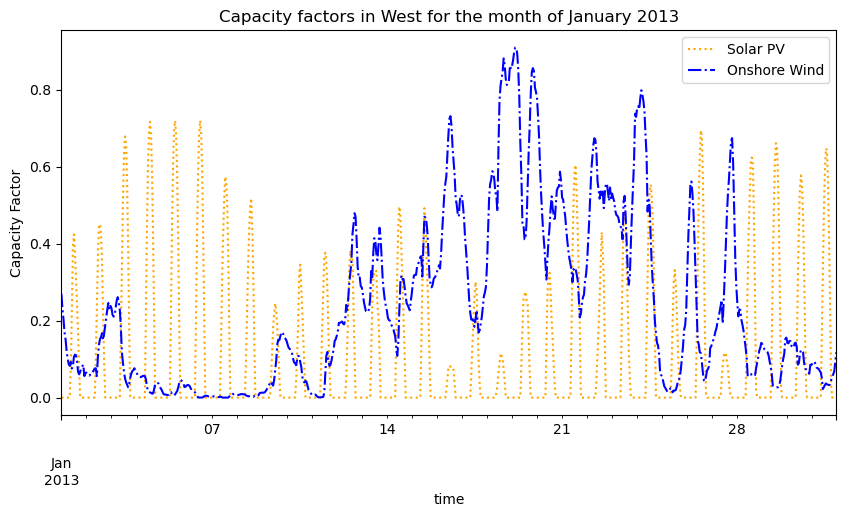

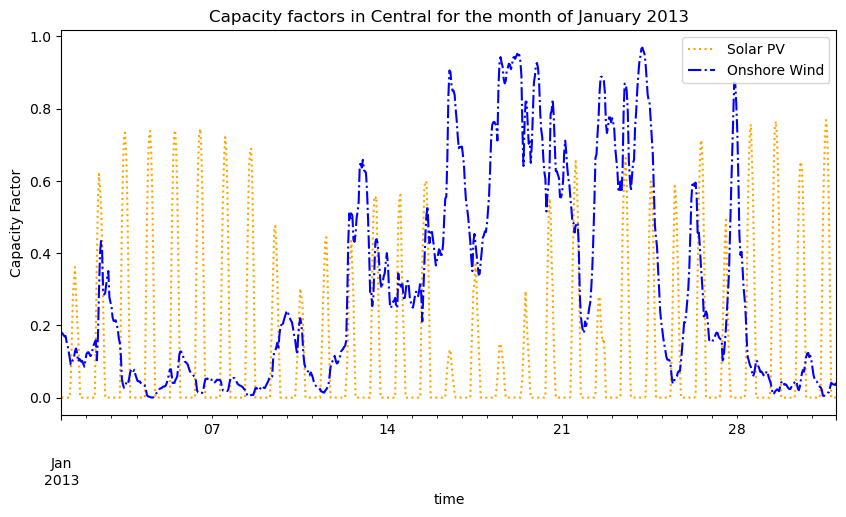

In [27]:
for region in region_names:
    solar_cap = pd.Series(solar_pv_df[region], index=solar_pv_df.index)
    onwind_cap = pd.Series(onshore_wind_df[region], index=onshore_wind_df.index)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    plt.title(f'Capacity factors in {region} for the month of January 2013')
    
    solar_cap.loc['2013-01'].plot(ax=ax, color="orange", linestyle=':', label='Solar PV')
    onwind_cap.loc['2013-01'].plot(ax=ax, color="blue", linestyle='-.', label='Onshore Wind')
    
    if region in eez_region_names:
        offwind_cap = pd.Series(offshore_wind_df[region], index=offshore_wind_df.index)
        offwind_cap.loc['2013-01'].plot(ax=ax, color="lightblue", label='Offshore Wind')
    
    plt.ylabel('Capacity Factor')
    plt.legend(loc="upper right")

for eez_region in eez_region_names:
    if eez_region not in region_names:
        fig, ax = plt.subplots(figsize=(10, 5))
        plt.title(f'Capacity factors in {eez_region} for the month of January 2013')
        
        offwind_cap = pd.Series(offshore_wind_df[eez_region], index=offshore_wind_df.index)
        offwind_cap.loc['2013-01'].plot(ax=ax, color="lightblue", label='Offshore Wind')
        
        plt.ylabel('Capacity Factor')
        plt.legend(loc="upper right")

plt.show()

# 4 Building exisiting network data

## 4.1 Data frames for profile creation

In [28]:
onwind_cap_fact = onshore_wind_df.copy()
offwind_cap_fact = offshore_wind_df.copy()
solar_cap_fact = solar_pv_df.copy()

In [29]:
points = points.to_crs(3035)
distance_bw_points = pd.concat({d: points.distance(p) for d, p in points.items()}, axis=1).div(1e3)

dict = {1: 'North',
        2: 'South',
        3: 'East',
        4: 'West',
        5: 'Central',}
distance_bw_points.rename(columns=dict, index=dict, inplace=True)
distance_bw_points

,North,South,East,West,Central
regions,,,,,
North,0.000000,634.698961,290.753312,381.866518,360.747132
South,634.698961,0.000000,468.577269,368.143211,275.132716
East,290.753312,468.577269,0.000000,415.878786,234.506078
West,381.866518,368.143211,415.878786,0.000000,221.683727
Central,360.747132,275.132716,234.506078,221.683727,0.000000


In [30]:
pp_path = "./data/7 global-power-plant-database/global_power_plant_database.csv"
power_plant = pd.read_csv(pp_path)
power_plant = power_plant[power_plant.country == 'ESP']

#No existing wind and solar pp's to be considered
power_plant = power_plant[~power_plant.primary_fuel.isin(['Solar', 'Wind'])]

#create geopandas and reset index
power_plant = gpd.GeoDataFrame(power_plant, geometry=gpd.points_from_xy(power_plant.longitude, power_plant.latitude))
power_plant.reset_index(drop=True, inplace=True)

In [31]:
power_plant = gpd.sjoin(power_plant, regions, how='left', op='within')
power_plant = power_plant.rename(columns={'index_right': 'region'})

In [32]:
power_plant[power_plant.region.isna()]

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry,region
7,ESP,Spain,ALCUDIA 1 GRUPO N 1,WRI1006172,533.80,39.8106,3.0913,Coal,Oil,NaN,...,NaN,NaN,2435.05,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (3.09130 39.81060),NaN
13,ESP,Spain,ARONA 1 GAS 1,WRI1006207,43.20,28.0996,-16.6810,Oil,NaN,NaN,...,NaN,NaN,90.00,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-16.68100 28.09960),NaN
23,ESP,Spain,BARRANCO DE TIRAJANA 7 VAPOR 3 (CC1),WRI1006230,646.26,27.8045,-15.4387,Oil,Gas,NaN,...,NaN,NaN,1346.49,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-15.43870 27.80450),NaN
43,ESP,Spain,CANDELARIA 9 VAPOR 5,WRI1006302,153.94,28.3548,-16.3727,Oil,NaN,NaN,...,NaN,NaN,320.73,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-16.37270 28.35480),NaN
46,ESP,Spain,CAS TRESORER TG3 CC2,WRI1006309,429.00,39.5672,2.6895,Gas,NaN,NaN,...,NaN,NaN,1016.87,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (2.68950 39.56720),NaN
102,ESP,Spain,ESCOMBRERAS GRUPO 1,WRI1006467,1199.25,7.5732,-0.9392,Gas,NaN,NaN,...,NaN,NaN,2842.61,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-0.93920 7.57320),NaN
111,ESP,Spain,GARONA VERDA,WRI1006494,14.95,0.7046,42.8025,Gas,NaN,NaN,...,NaN,NaN,35.43,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (42.80250 0.70460),NaN
114,ESP,Spain,GRANADILLA 1 GAS 1,WRI1006506,693.34,28.0863,-16.4939,Oil,Gas,NaN,...,NaN,NaN,1444.58,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-16.49390 28.08630),NaN
115,ESP,Spain,GRUPO TURBO-GENERADOR 2 TIRME-SON REUS,WRI1006520,74.80,39.5694,2.6502,Waste,NaN,NaN,...,NaN,NaN,26.05,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (2.65020 39.56940),NaN
118,ESP,Spain,GUIA DE ISORA GAS 1,WRI1006524,43.10,28.2115,-16.7795,Oil,NaN,NaN,...,NaN,NaN,89.79,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (-16.77950 28.21150),NaN


In [33]:
def find_nearest_region(row, regions):
    if pd.isna(row['region']):
        distances = regions.distance(row.geometry)
        nearest_region = distances.idxmin()
        return nearest_region
    return row['region']

# Apply the function to assign nearest region for NaN values
power_plant['region'] = power_plant.apply(find_nearest_region, axis=1, regions=regions)

power_plant[power_plant.region.isna()]

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry,region


In [34]:
# Grouping powerplants with respect to primary fuel and capacity
grp_power_plant = power_plant.groupby(["region","primary_fuel"]).capacity_mw.sum().unstack().fillna(0)
grp_power_plant = grp_power_plant.drop(axis = 1 , columns = ["Biomass" , "Waste"])
grp_power_plant

primary_fuel,Coal,Gas,Hydro,Nuclear,Oil
region,,,,,
Central,0.00,849.240,991.590,1003.41,56.830
East,1654.57,9511.209,5064.970,4099.75,785.410
North,2682.45,4826.288,4076.930,0.00,978.401
South,1989.40,10109.841,769.090,0.00,2846.030
West,2456.89,862.566,4756.556,2016.90,0.000


In [35]:
# Hydropower plants
hydro_pp = grp_power_plant['Hydro'].sum()
hydro_generation = power_plant.groupby("primary_fuel").estimated_generation_gwh_2017.sum().loc["Hydro"]* 1e3 #Converting to MWh
cf_hydro = hydro_generation / (hydro_pp * 8760)
grp_power_plant["Hydro"] = grp_power_plant["Hydro"] * cf_hydro
grp_power_plant

primary_fuel,Coal,Gas,Hydro,Nuclear,Oil
region,,,,,
Central,0.00,849.240,161.516351,1003.41,56.830
East,1654.57,9511.209,825.013838,4099.75,785.410
North,2682.45,4826.288,664.075733,0.00,978.401
South,1989.40,10109.841,125.274166,0.00,2846.030
West,2456.89,862.566,774.777446,2016.90,0.000


## 4.2 Considering Population and Load

In [36]:
load_path = "./data/load.csv"
load_series = pd.read_csv(load_path, index_col="time")
load_series = load_series["ES"]
load_series = load_series.to_frame()

#https://www.statista.com/statistics/445549/population-of-spain-by-autonomous-community/

state_population = {
    "Andalucía": 8577627,
    "Aragón": 1349513,
    "Cantabria": 588567,
    "Castilla-La Mancha": 2080922,
    "Castilla y León": 2382401,
    "Cataluña": 7899327,
    "Ceuta y Melilla": 168434,
    "Comunidad de Madrid": 6849617,
    "Comunidad Foral de Navarra": 672242,
    "Comunidad Valenciana": 5218840,
    "Extremadura": 1054359,
    "Galicia": 2699933,
    "La Rioja": 322333,
    "País Vasco": 2219731,
    "Principado de Asturias": 1006623,
    "Región de Murcia": 1552815
}

state_population = pd.DataFrame.from_dict(state_population,orient="index")
state_population.rename(columns = {0:'total_population'}, inplace = True)
state_population["percentage"] = state_population["total_population"]/state_population.total_population.sum()*100
state_population["regions"] = [2,3,1,5,4,3,2,5,1,3,4,1,4,1,1,2]

percentage_sum = state_population.groupby("regions")["percentage"].sum().to_frame()
total_population_sum = state_population.groupby("regions")["total_population"].sum().to_frame()
region_population = percentage_sum.join(total_population_sum)
region_population.rename(index=dict, inplace=True)
region_population

,percentage,total_population
regions,,
North,16.098941,7187096
South,23.069262,10298876
East,32.407293,14467680
West,8.420288,3759093
Central,20.004216,8930539


In [37]:
for i in range(len(region_population)):
    load_series[region_population.index[i]] = load_series["ES"].values * region_population.iloc[i,0]/100

load_series = load_series.drop(columns='ES')
load_series.head()

,North,South,East,West,Central
time,,,,,
2013-01-01 00:00:00,4804.361800,6884.494994,9671.217572,2512.842852,5969.802049
2013-01-01 01:00:00,4638.817732,6647.275702,9337.976079,2426.257735,5764.100364
2013-01-01 02:00:00,4614.964800,6613.095222,9289.959942,2413.781849,5734.461197
2013-01-01 03:00:00,4610.282192,6606.385196,9280.533815,2411.332688,5728.642683
2013-01-01 04:00:00,4630.324966,6635.105843,9320.880076,2421.815733,5753.547426


In [38]:
load_series.index = pd.to_datetime(load_series.index)
onwind_cap_fact.index = load_series.index
offwind_cap_fact.index = load_series.index
solar_cap_fact.index = load_series.index

# Downsampling the time series to a 3-hourly resolution
resolution = 3
load_series = load_series.resample(f"{resolution}H").first()
onwind_cap_fact = onwind_cap_fact.resample(f"{resolution}H").first()
offwind_cap_fact = onwind_cap_fact.resample(f"{resolution}H").first()
solar_cap_fact = solar_cap_fact.resample(f"{resolution}H").first()

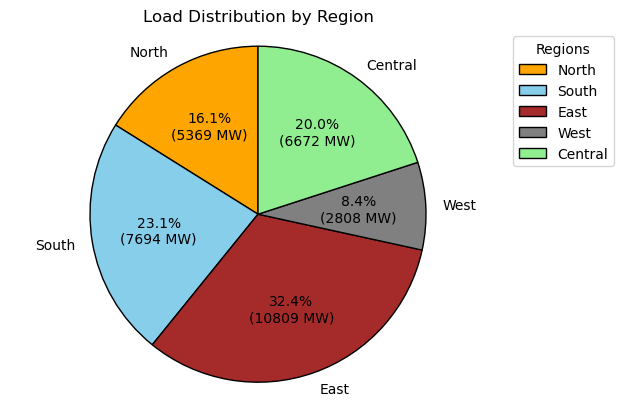

In [39]:
loads_mean = load_series.mean()
loads_mean = pd.DataFrame(loads_mean, columns = ['Average_Load'])

wp = {'linewidth': 1, 'edgecolor': "black"}
overall_average_capacity = loads_mean['Average_Load'].mean()

# Create the pie chart
fig, ax = plt.subplots()

def func(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%\n({:d} MW)".format(pct, absolute)

wedges, texts, autotexts = ax.pie(loads_mean['Average_Load'], 
                                  labels= region_names, 
                                  autopct= lambda pct: func(pct, loads_mean.Average_Load),
                                  startangle= 90, 
                                  colors= colors, 
                                  wedgeprops= wp)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')

ax.legend(wedges, region_names,
          title ="Regions",
          loc ="upper left",
          bbox_to_anchor =(1, 0, 0.5, 1))



plt.title('Load Distribution by Region')
plt.show()

## 4.4 VOM and FOM cost addition

In [40]:
year = 2025
cost_url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(cost_url, index_col=[0,1])

In [41]:
def annuity_func(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [42]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [43]:
annuity = costs.apply(lambda x: annuity_func(x['discount rate'], x['lifetime']), axis=1)
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"] # Lecture: Investement Dynamics slide 28

# 5 Building the pypsa network

In [44]:
n = pypsa.Network()

In [45]:
points = provinces.representative_point()
points = points.to_frame()
points["x"] = points.centroid.x
points["y"] = points.centroid.y

## 5.1 Adding Bus

In [46]:
for i in range(1,6):
    n.add("Bus", f"{region_names[i-1]}",y=points.iloc[i-1,2] , x=points.iloc[i-1,1])

In [47]:
n.set_snapshots(load_series.index) # Setting Load time series dates as snapshot

In [48]:
n.snapshot_weightings.loc[:,:] = resolution

## 5.2 Adding Carriers

In [49]:
carriers = ["offwind","onwind","solar","coal", "gas", "hydro", "nuclear", "oil","hydrogen storage underground", "battery storage"]

n.madd(
    "Carrier",
    carriers,
    color=["dodgerblue", "aquamarine", "gold","grey","indianred","green","orange","chocolate","magenta", "yellowgreen"],
    co2_emissions=[costs.at[c, "CO2 intensity"] for c in carriers]
)

n.add(
    "Carrier",
    "HVAC",
    color = "brown",
    co2_emissions = 0
)

## 5.3 Adding Generators

In [50]:
# Adding existing generators to the network
generators = ["coal" , "gas" , "hydro" , "nuclear" , "oil"]

for i in range(1,6):
    for g in generators:
        n.add(
            "Generator",
            f"{g} {region_names[i-1]}",
            bus= f'{region_names[i-1]}',
            carrier= f"{g}",
            capital_cost=costs.at[g, "capital_cost"],
            marginal_cost=costs.at[g, "marginal_cost"],
            efficiency=costs.at[g, "efficiency"],
            p_nom_extendable=False,
            p_nom = grp_power_plant.iloc[i-1, generators.index(g)],
        )

In [51]:
# Adding variable renewable generators
myVars = globals()
for tech in ["solar","onwind"]:
    for i in range(1,6):
        n.add(
            "Generator",
            f"{tech} {region_names[i-1]}",
            bus=f'{region_names[i-1]}',
            carrier=f"{tech}",
            p_max_pu=myVars[f"{tech}_cap_fact"][region_names[i-1]].values,
            capital_cost=costs.at[f"{tech}", "capital_cost"],
            marginal_cost=costs.at[f"{tech}", "marginal_cost"],
            efficiency=costs.at[f"{tech}", "efficiency"],
            p_nom_extendable=True,
            p_nom_max = myVars[f"df_{tech}_cap"].at[region_names[i-1] , "Cap per region"] * 6
        )

for tech in ["offwind"]:
    for j in range(1,3):
        n.add(
            "Generator",
            f"{tech} {eez_region_names[j-1]}",
            bus=f'{eez_region_names[j-1]}',
            carrier=f"{tech}",
            p_max_pu=myVars[f"{tech}_cap_fact"][eez_region_names[j-1]].values,
            capital_cost=costs.at[f"{tech}", "capital_cost"],
            marginal_cost=costs.at[f"{tech}", "marginal_cost"],
            efficiency=costs.at[f"{tech}", "efficiency"],
            p_nom_extendable=True,
            p_nom_max = myVars[f"df_{tech}_cap"].at[eez_region_names[j-1] , "Cap per region"] * 6
        )

In [52]:
for i in range(1,6):
    n.add(
        "Load",
        f"Demand {region_names[i-1]}",
        bus=f"{region_names[i-1]}",
        p_set=load_series.iloc[:,i-1],
    )

## 5.4 Adding Storages and Links

In [53]:
#Adding Battery storage
for i in range(1,6):
    n.add(
        "StorageUnit",
        f"battery storage {region_names[i-1]}",
        bus=f'{region_names[i-1]}',
        carrier="battery storage",
        max_hours=6,
        capital_cost=costs.at["battery inverter", "capital_cost"] + 6 * costs.at["battery storage", "capital_cost"],
        efficiency_store=costs.at["battery inverter", "efficiency"],
        efficiency_dispatch=costs.at["battery inverter", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
    )

In [54]:
#Adding Hydrogen storage
capital_costs = (
        costs.at["electrolysis", "capital_cost"] +
        costs.at["fuel cell", "capital_cost"] +
        300 * costs.at["hydrogen storage underground", "capital_cost"]
)

for i in range(1,6):
    n.add(
        "StorageUnit",
        f"hydrogen storage underground {region_names[i-1]}",
        bus=f'{region_names[i-1]}',
        carrier="hydrogen storage underground",
        max_hours=300,
        capital_cost=capital_costs,
        efficiency_store=costs.at["electrolysis", "efficiency"],
        efficiency_dispatch=costs.at["fuel cell", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
    )

In [55]:
n.add(
    "Link",
    name = "N-W",
    bus0 = "North",
    bus1 = "West",
    efficiency = 1,
    marginal_cost = 0,
    p_min_pu = -1,
    length = distance_bw_points.iloc[0,3]*1.5,
    capital_cost = 600 * distance_bw_points.iloc[0,3]*1.5,
    p_nom_extendable = True,
    carrier = "HVAC",
)

n.add(
    "Link",
    name = "W-S",
    bus0 = "West",
    bus1 = "South",
    efficiency = 1,
    marginal_cost = 0,
    p_min_pu = -1,
    length = distance_bw_points.iloc[3,1]*1.5,
    capital_cost = 600 * distance_bw_points.iloc[3,1]*1.5,
    p_nom_extendable = True,
    carrier = "HVAC",
)

n.add(
    "Link",
    name = "S-E",
    bus0 = "South",
    bus1 = "East",
    efficiency = 1,
    marginal_cost = 0,
    p_min_pu = -1,
    length = distance_bw_points.iloc[1,2]*1.5,
    capital_cost = 600 * distance_bw_points.iloc[1,2]*1.5,
    p_nom_extendable = True,
    carrier = "HVAC",
)

n.add(
    "Link",
    name = "E-N",
    bus0 = "East",
    bus1 = "North",
    efficiency = 1,
    marginal_cost = 0,
    p_min_pu = -1,
    length = distance_bw_points.iloc[2,0]*1.5,
    capital_cost = 600 * distance_bw_points.iloc[2,0]*1.5,
    p_nom_extendable = True,
    carrier = "HVAC",
)

In [56]:
n.add(
    "Link",
    name = "C-W",
    bus0 = "Central",
    bus1 = "West",
    efficiency = 1,
    marginal_cost = 0,
    p_min_pu = -1,
    length = distance_bw_points.iloc[4,3]*1.5,
    capital_cost = 600 * distance_bw_points.iloc[4,3]*1.5,
    p_nom_extendable = True,
    carrier = "HVAC",
)

n.add(
    "Link",
    name = "C-E",
    bus0 = "Central",
    bus1 = "East",
    efficiency = 1,
    marginal_cost = 0,
    p_min_pu = -1,
    length = distance_bw_points.iloc[4,2]*1.5,
    capital_cost = 600 * distance_bw_points.iloc[4,2]*1.5,
    p_nom_extendable = True,
    carrier = "HVAC",
)

n.add(
    "Link",
    name = "C-S",
    bus0 = "Central",
    bus1 = "South",
    efficiency = 1,
    marginal_cost = 0,
    p_min_pu = -1,
    length = distance_bw_points.iloc[4,1]*1.5,
    capital_cost = 600 * distance_bw_points.iloc[4,1]*1.5,
    p_nom_extendable = True,
    carrier = "HVAC",
)


In [57]:
distance_bw_points.iloc[4,0]

360.7471319524554

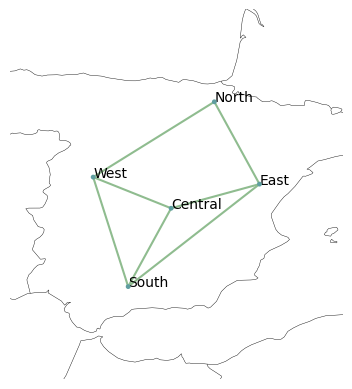

In [58]:
n.plot(margin=0.5, bus_sizes=0.005)
for i, txt in enumerate(region_names):
    plt.annotate(txt, (points.x[i], points.y[i]))

# 6 Optimization of the network

## 6.1 Current Situation

In [59]:
n.lopf(solver_name='gurobi')

INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.74s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Set parameter Username
Academic license - for non-commercial use only - expires 2025-07-10
Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-fwdecdjj.lp
Reading time = 1.48 seconds
obj: 475960 rows, 216110 columns, 912636 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 475960 rows, 216110 columns and 912636 nonzeros
Model fingerprint: 0x8b682e3a
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 1e+06]
  RHS range        [6e+01, 1e+04]
Presolve removed 275804 rows and 18845 columns
Presolve time: 0.64s
Presolved: 200156 rows, 197265 columns, 617988 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 

INFO:pypsa.linopf:Optimization successful. Objective value: 9.38e+09


('ok', 'optimal')

In [60]:
def plot_dispatch(n, time, ymin, ymax):

    p_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().div(1e3)

    if not n.storage_units.empty:
        sto = n.storage_units_t.p.groupby(n.storage_units.carrier, axis=1).sum().div(1e3)
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)

    fig, ax = plt.subplots(figsize=(15, 12))

    color = p_by_carrier.columns.map(n.carriers.color)

    p_by_carrier.where(p_by_carrier>0).loc[time].plot.area(
        ax=ax,
        linewidth=0,
        color=color,
    )
    plt.rcParams.update({'font.size': 14})

    charge = p_by_carrier.where(p_by_carrier<0).dropna(how='all', axis=1).loc[time]

    if not charge.empty:

        charge.plot.area(
            ax=ax,
            linewidth=0,
            color=charge.columns.map(n.carriers.color),
        )

    n.loads_t.p_set.sum(axis=1).loc[time].div(1e3).plot(ax=ax, c='k')
    
    plt.legend(loc=(1.01,0))
    ax.set_ylabel("GW")
    
    #set axis limit to min and max overall
    ax.set_ylim(ymin, ymax)

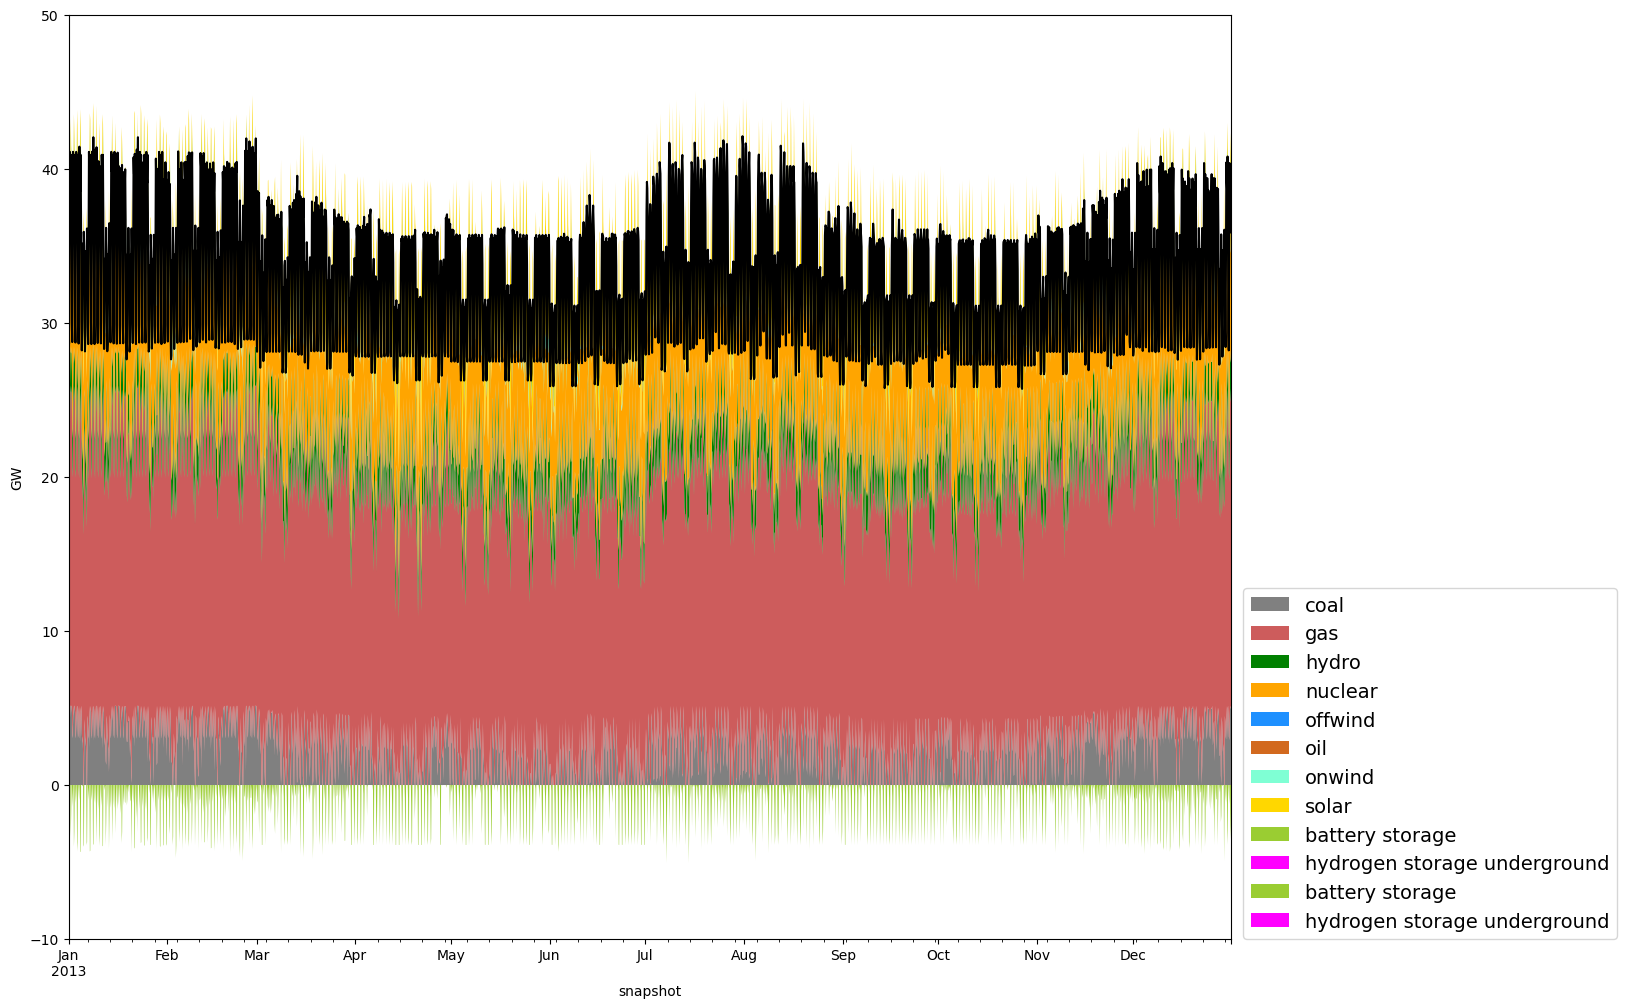

In [61]:
plot_dispatch(n, "2013", -10, 50)

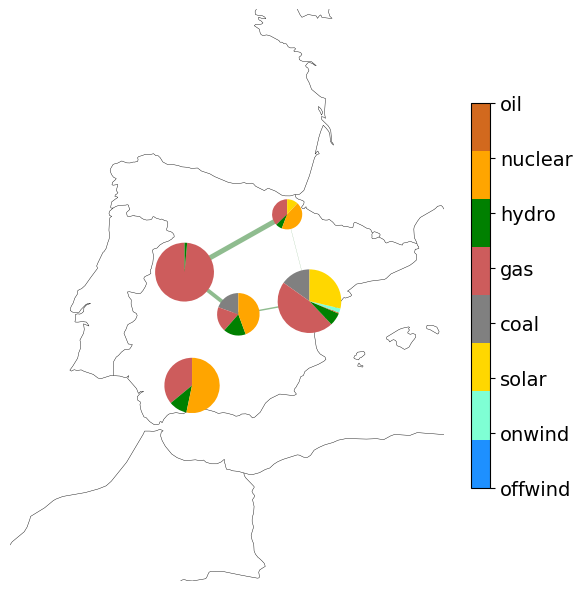

In [62]:
fig = plt.figure(figsize=(7,10))
ax = plt.axes(projection=ccrs.epsg(3035))
capacities = n.generators_t.p.groupby([n.generators.bus, n.generators.carrier], axis = 1).sum().sum()
colorforcarriers = ["dodgerblue", "aquamarine", "gold","grey","indianred","green","orange","chocolate"]
carrierforcolors = ["offwind","onwind","solar","coal" , "gas" , "hydro" , "nuclear" , "oil"]
norm = plt.Normalize(vmin=n.links_t.p0.iloc[0].abs().min(), vmax=n.links_t.p0.iloc[0].abs().max())

n.plot(
    ax=ax,
    margin=0.9,
    bus_sizes=capacities / 3e7,
    link_norm=norm,
    link_cmap='jet',
    link_widths= n.links_t.p0.iloc[0].abs() / 1e3
)

norm = mpl.colors.Normalize(vmin=1, vmax=8)

cmap = ListedColormap(colorforcarriers)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, shrink=0.5)
cbar.ax.set_yticklabels(carrierforcolors)

plt.rcParams.update({'font.size': 8})

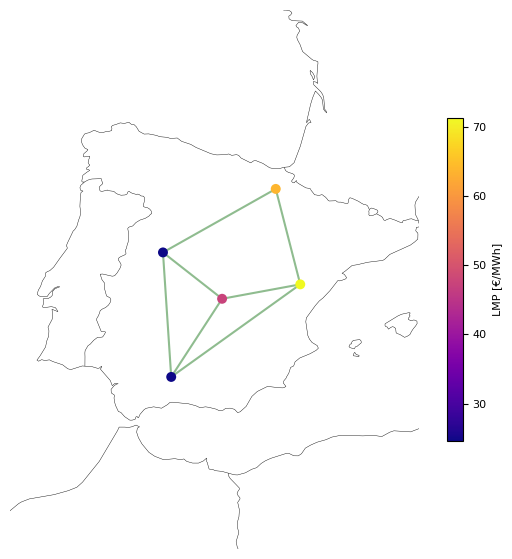

In [63]:
fig = plt.figure(figsize=(7,7))
ax = plt.axes(projection=ccrs.epsg(3035))

norm = plt.Normalize(vmin=n.buses_t.marginal_price.mean().min(), vmax=n.buses_t.marginal_price.mean().max()) # €/MWh

n.plot(
    margin=0.7,
    ax=ax,
    bus_colors=n.buses_t.marginal_price.mean(),
    bus_cmap='plasma',
    bus_norm=norm,
);

sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, label="LMP [€/MWh]", shrink=0.6)


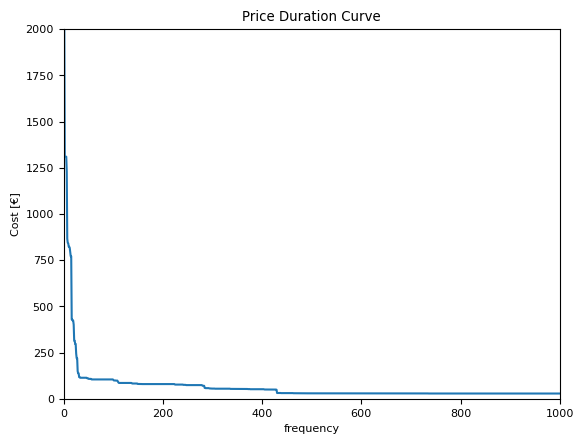

In [64]:
price_duration=n.buses_t.marginal_price
price_duration=price_duration.mean(axis=1)
price_duration=price_duration.sort_values(ascending=False).reset_index(drop=True)
price_duration.plot(ylabel='Cost [€]', xlabel='frequency', title='Price Duration Curve')
plt.xlim(0,1000)
plt.ylim(0,2000)
plt.show()

In [65]:
n.buses_t.marginal_price.mean()

Bus
North      63.800861
South      24.568000
East       71.338813
West       24.568000
Central    47.343725
dtype: float64

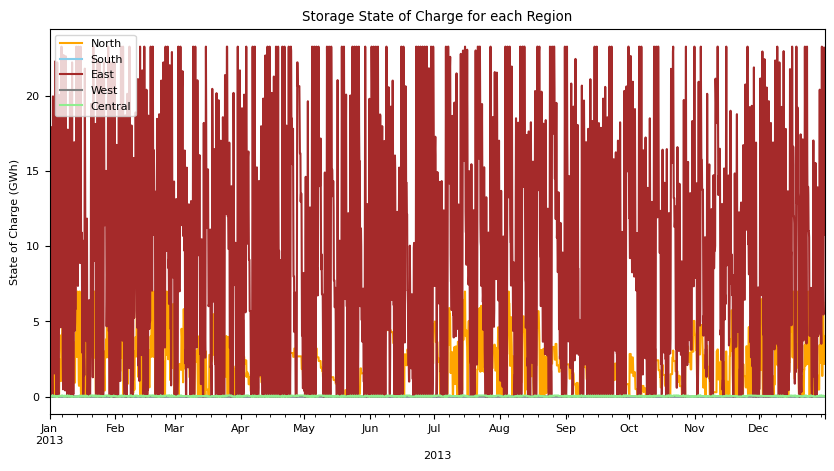

In [66]:
regioncolors = ["orange", "skyblue", "brown","grey", "lightgreen"]
i = 0
soc = n.storage_units_t.state_of_charge.groupby([n.storage_units.bus], axis=1).sum()

fig, ax = plt.subplots(figsize=(10,5))

for region in region_names:
    x = soc[region]/1e3
    x.plot(color = regioncolors[i], label=region)
    i += 1
    
plt.title('Storage State of Charge for each Region')
plt.legend(loc='upper left')
plt.ylabel('State of Charge (GWh)')
plt.xlabel('2013')
plt.show()

In [67]:
def system_cost(n):
    tsc = n.statistics.capex() + n.statistics.opex()
    return tsc.droplevel(0).div(1e6) # million €/a

In [68]:
demand = n.snapshot_weightings.generators @ n.loads_t.p_set.sum(axis=1)
n_costperMW = system_cost(n).sum()*1e6 / demand.sum()
print(f'Total system cost is € {round(system_cost(n).sum()/ 1e3, 2)} Billion @ {round(n_costperMW,1)} €/MWh')

Total system cost is € 15.14 Billion @ 51.8 €/MWh


In [69]:
demand = n.snapshot_weightings.generators @ n.loads_t.p_set.sum(axis=1)

In [70]:
n.storage_units.p_nom_opt

StorageUnit
battery storage North                   1163.871538
battery storage South                      0.000000
battery storage East                    3878.398711
battery storage West                       0.000000
battery storage Central                   12.423784
hydrogen storage underground North         0.000000
hydrogen storage underground South         0.000000
hydrogen storage underground East          0.000000
hydrogen storage underground West          0.000000
hydrogen storage underground Central       0.000000
Name: p_nom_opt, dtype: float64

## 6.2 No CO2 Emissions

In [71]:
n1 = n.copy()

In [72]:
n1.add(
    "GlobalConstraint",
    "CO2Limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=0,
)

In [73]:
for i in range(1,6):
    n1.remove("Generator",f"gas {dict[i]}")
    n1.remove("Generator",f"coal {dict[i]}")
    n1.remove("Generator",f"oil {dict[i]}")

In [74]:
n1.lopf(solver_name='gurobi')

INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.52s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-lmn6e2wh.lp
Reading time = 1.14 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0xf71536f2
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 1e+06]
  RHS range        [1e+02, 1e+04]
Presolve removed 188205 rows and 13005 columns
Presolve time: 0.73s
Presolved: 200156 rows, 159305 columns, 580028 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.11s

Barrier statistics:
 Dense cols : 29
 Free vars  : 20440
 AA' NZ     : 5.405e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10


('ok', 'optimal')

In [75]:
n1.generators.p_nom_opt

Generator
hydro North          161.516351
nuclear North       1003.410000
hydro South          825.013838
nuclear South       4099.750000
hydro East           664.075733
nuclear East           0.000000
hydro West           125.274166
nuclear West           0.000000
hydro Central        774.777446
nuclear Central     2016.900000
solar North        18158.305948
solar South        23830.062807
solar East         66342.402799
solar West         16064.217925
solar Central      22870.490353
onwind North       12415.301581
onwind South        1171.513997
onwind East         9341.565186
onwind West         4550.455047
onwind Central      8292.820460
offwind North          0.000000
offwind South          0.000000
Name: p_nom_opt, dtype: float64

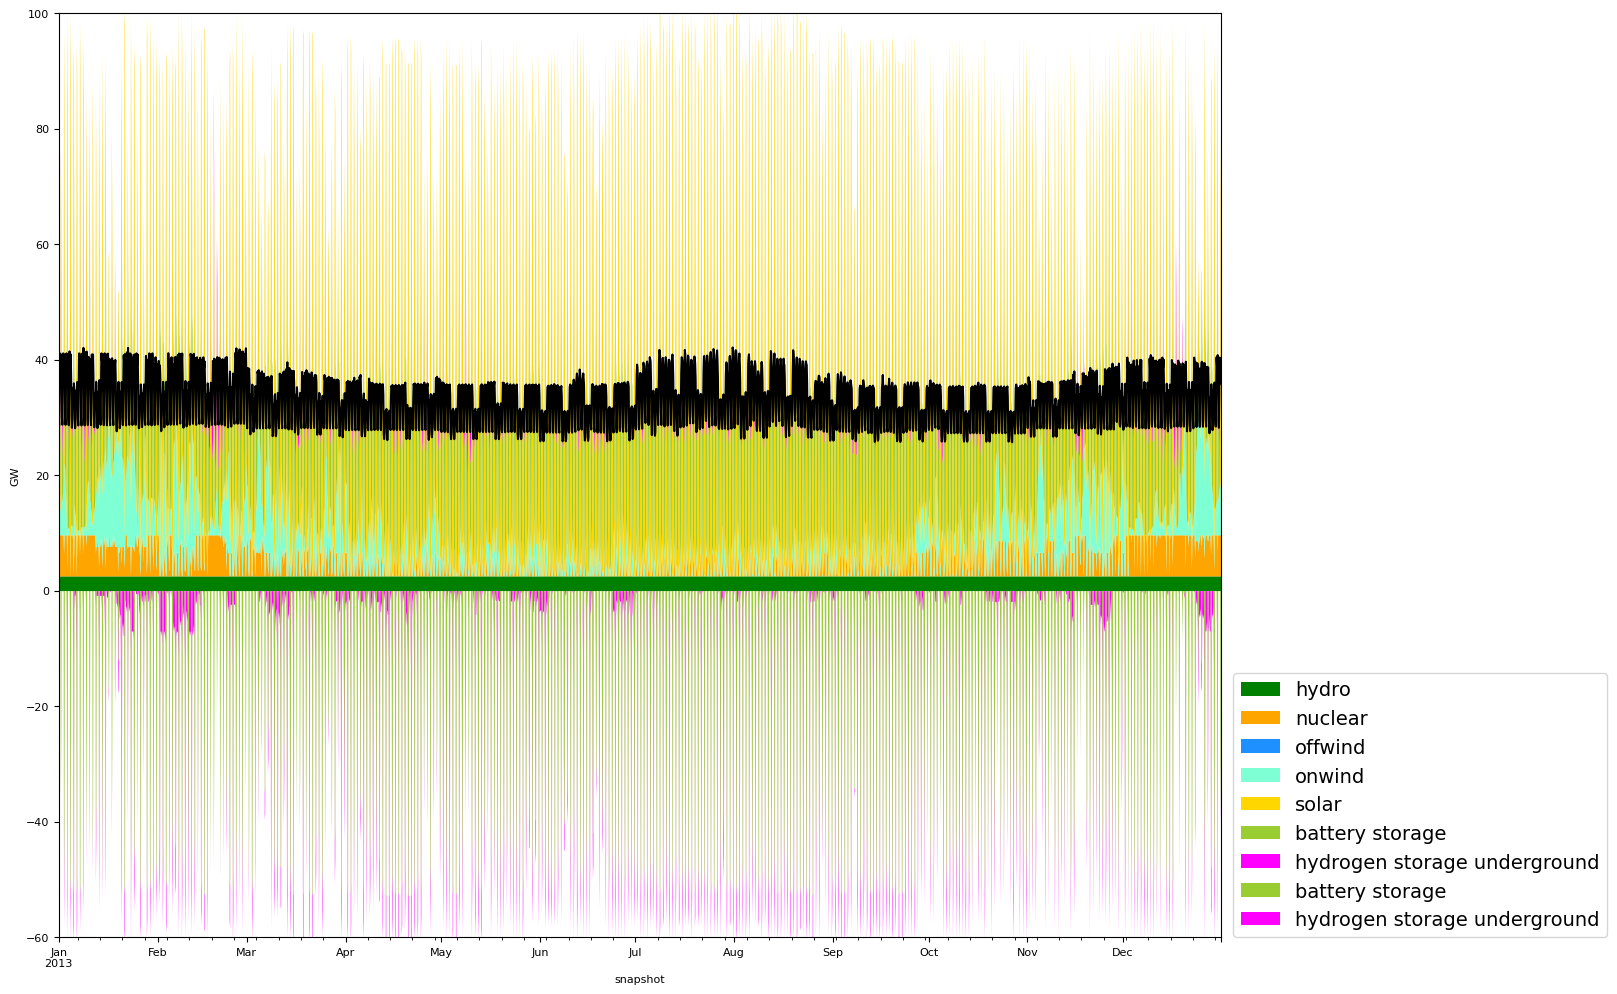

In [76]:
plot_dispatch(n1, "2013", -60, 100)

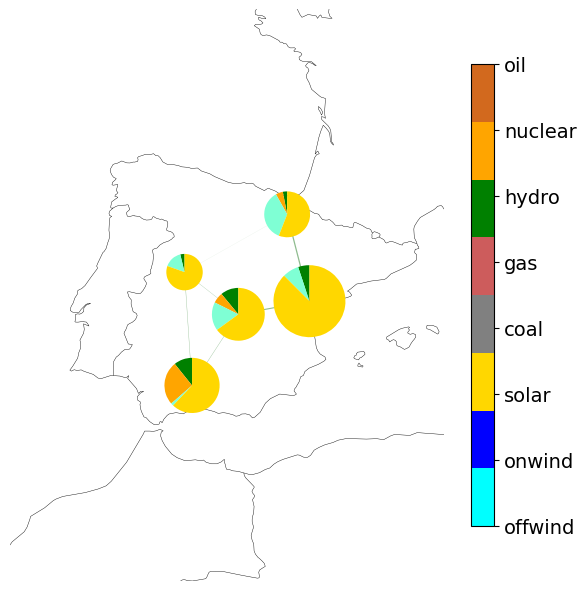

In [77]:
capacities = n1.generators_t.p.groupby([n1.generators.bus, n1.generators.carrier], axis = 1).sum().sum()
carriers = n1.generators.carrier.unique()
colorforcarriers = ["cyan","blue","gold","grey","indianred","green","orange","chocolate"]
carrierforcolors = ["offwind","onwind","solar","coal" , "gas" , "hydro" , "nuclear" , "oil"]

fig = plt.figure(figsize=(7,10))
ax = plt.axes(projection=ccrs.epsg(3035))

norm = plt.Normalize(vmin=n1.links_t.p0.iloc[0].abs().min(), vmax=n1.links_t.p0.iloc[0].abs().max())

n1.plot(
    ax=ax,
    margin=0.9,
    bus_sizes=capacities / 3e7,
    link_norm=norm,
    link_cmap='jet',
    link_widths= n1.links_t.p0.iloc[0].abs() / 1e3
)

norm = mpl.colors.Normalize(vmin=1, vmax=8)

cmap = ListedColormap(colorforcarriers)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
cbar.ax.set_yticklabels(carrierforcolors)

plt.rcParams.update({'font.size': 10})

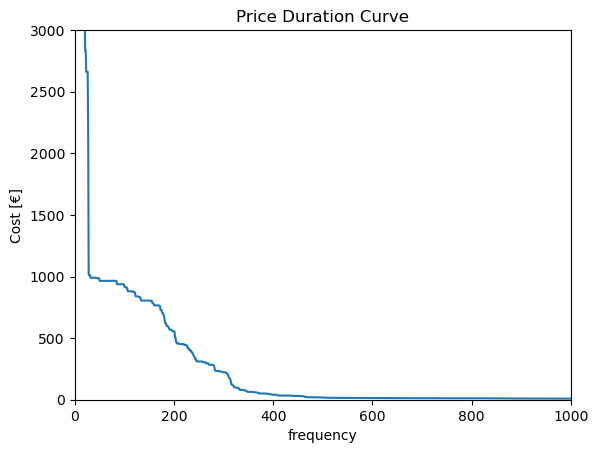

In [78]:
price_duration=n1.buses_t.marginal_price
price_duration=price_duration.mean(axis=1)
price_duration=price_duration.sort_values(ascending=False).reset_index(drop=True)
price_duration.plot(ylabel='Cost [€]', xlabel='frequency', title='Price Duration Curve')
plt.xlim(0,1000)
plt.ylim(0,3000)
plt.show()

In [79]:
n1.buses_t.marginal_price.mean()

Bus
North      113.536168
South      112.344351
East       112.303322
West       124.197132
Central    111.246075
dtype: float64

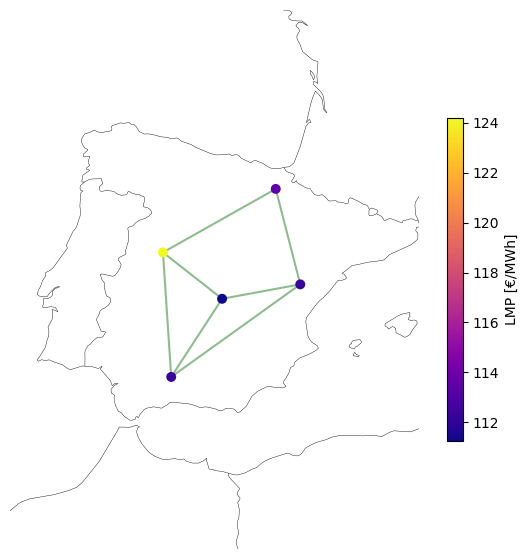

In [80]:
fig = plt.figure(figsize=(7,7))
ax = plt.axes(projection=ccrs.epsg(3035))

norm = plt.Normalize(vmin=n1.buses_t.marginal_price.mean().min(), vmax=n1.buses_t.marginal_price.mean().max()) # €/MWh

n1.plot(
    margin=0.7,
    ax=ax,
    bus_colors=n1.buses_t.marginal_price.mean(),
    bus_cmap='plasma',
    bus_norm=norm,
);

sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, label="LMP [€/MWh]", shrink=0.6)

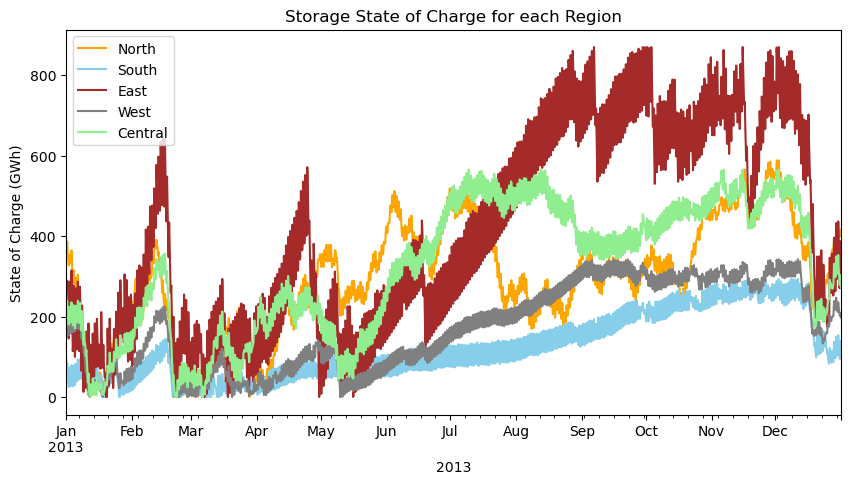

In [81]:
regioncolors = ["orange", "skyblue", "brown","grey", "lightgreen"]
i = 0
soc = n1.storage_units_t.state_of_charge.groupby([n1.storage_units.bus], axis=1).sum()

fig, ax = plt.subplots(figsize=(10,5))

for region in region_names:
    x = soc[region]/1e3
    x.plot(color = regioncolors[i], label=region)
    i += 1
    
plt.title('Storage State of Charge for each Region')
plt.legend(loc='upper left')
plt.ylabel('State of Charge (GWh)')
plt.xlabel('2013')
plt.show()

In [82]:
demand = n1.snapshot_weightings.generators @ n1.loads_t.p_set.sum(axis=1)
n1_costperMW = system_cost(n1).sum()*1e6 / demand.sum()
print(f'Total system cost is € {round(system_cost(n1).sum()/ 1e3, 2)} Billion @ {round(n1_costperMW,1)} €/MWh')

Total system cost is € 18.9 Billion @ 64.7 €/MWh


## 6.3 Renewables Only

In [83]:
n2 = n1.copy()

In [84]:
for i in range(1,6):
    n2.remove("Generator",f"nuclear {dict[i]}")

In [85]:
n2.lopf(solver_name='gurobi')

INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.0s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-3wyif10w.lp
Reading time = 1.13 seconds
obj: 359161 rows, 157710 columns, 737436 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 359161 rows, 157710 columns and 737436 nonzeros
Model fingerprint: 0xee35fc9c
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 1e+06]
  RHS range        [1e+02, 1e+04]
Presolve removed 159006 rows and 7166 columns
Presolve time: 0.64s
Presolved: 200155 rows, 150544 columns, 571278 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.13s

Barrier statistics:
 Dense cols : 29
 Free vars  : 20439
 AA' NZ     : 5.405e+05
 Fac

INFO:pypsa.linopf:Optimization successful. Objective value: 3.23e+10


('ok', 'optimal')

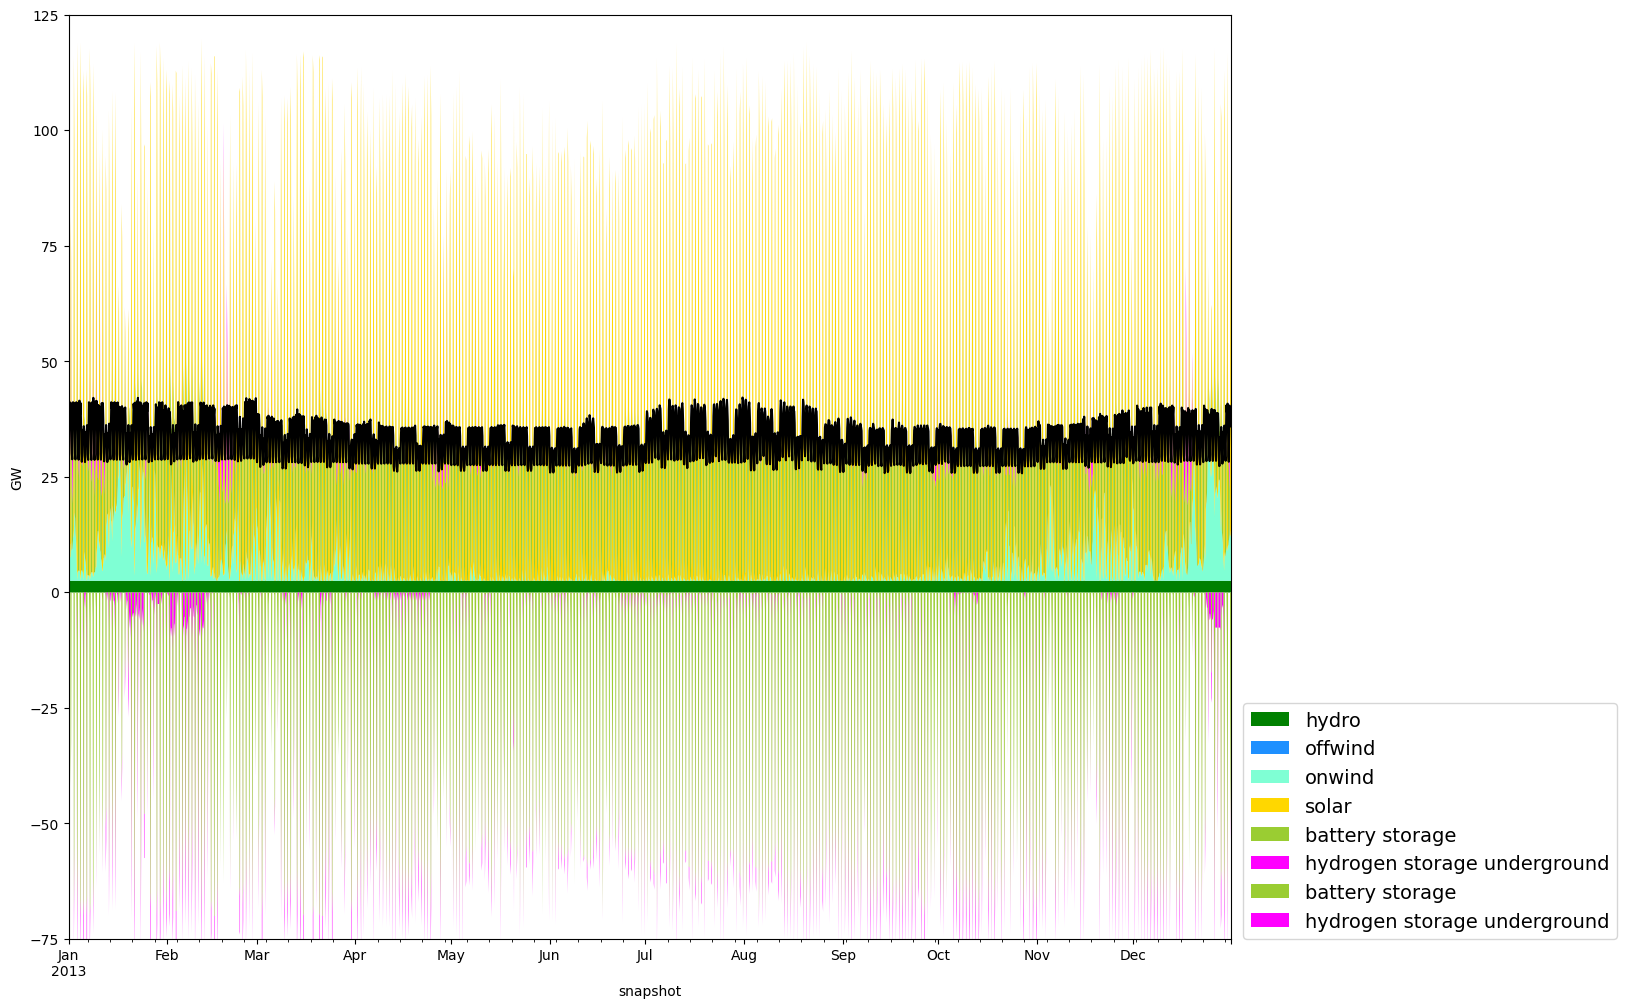

In [86]:
plot_dispatch(n2, "2013", -75, 125)

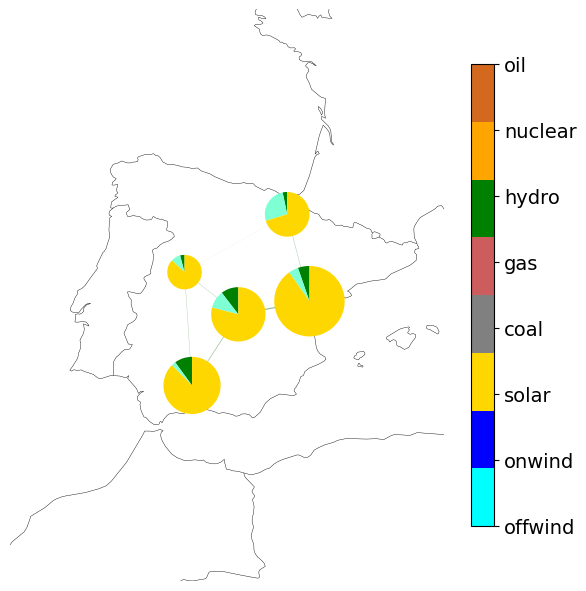

In [87]:
capacities = n2.generators_t.p.groupby([n2.generators.bus, n2.generators.carrier], axis = 1).sum().sum()
carriers = n2.generators.carrier.unique()
colorforcarriers = ["cyan","blue","gold","grey","indianred","green","orange","chocolate"]
carrierforcolors = ["offwind","onwind","solar","coal" , "gas" , "hydro" , "nuclear" , "oil"]

fig = plt.figure(figsize=(7,10))
ax = plt.axes(projection=ccrs.epsg(3035))

norm = plt.Normalize(vmin=n2.links_t.p0.iloc[0].abs().min(), vmax=n2.links_t.p0.iloc[0].abs().max())

n2.plot(
    ax=ax,
    margin=0.9,
    bus_sizes=capacities / 3e7,
    link_norm=norm,
    link_cmap='jet',
    link_widths= n2.links_t.p0.iloc[0].abs() / 1e3
)

norm = mpl.colors.Normalize(vmin=1, vmax=8)

cmap = ListedColormap(colorforcarriers)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
cbar.ax.set_yticklabels(carrierforcolors)

plt.rcParams.update({'font.size': 10})

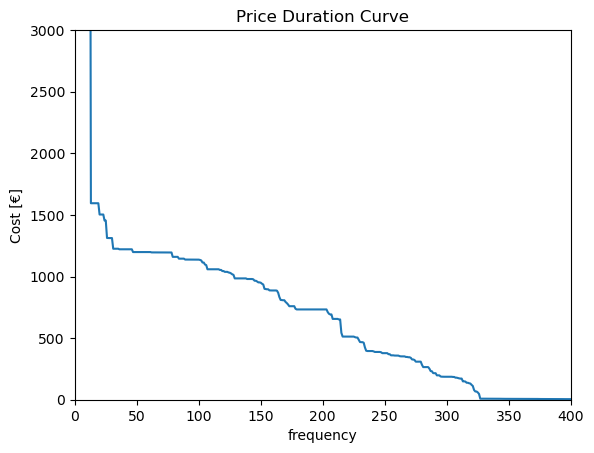

In [88]:
price_duration=n2.buses_t.marginal_price
price_duration=price_duration.mean(axis=1)
price_duration=price_duration.sort_values(ascending=False).reset_index(drop=True)
price_duration.plot(ylabel='Cost [€]', xlabel='frequency', title='Price Duration Curve')
plt.xlim(0,400)
plt.ylim(0,3000)
plt.show()

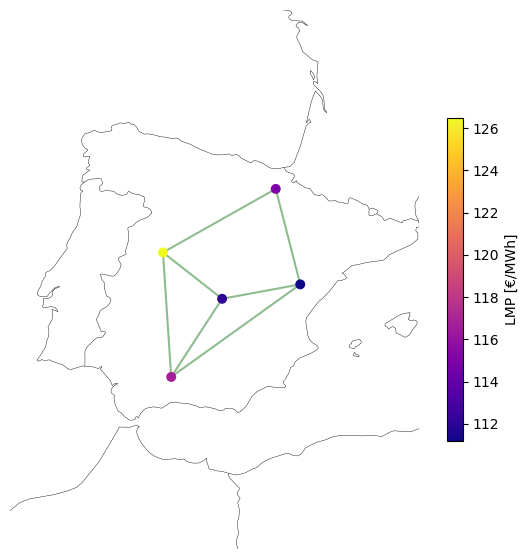

In [89]:
fig = plt.figure(figsize=(7,7))
ax = plt.axes(projection=ccrs.epsg(3035))

norm = plt.Normalize(vmin=n2.buses_t.marginal_price.mean().min(), vmax=n2.buses_t.marginal_price.mean().max()) # €/MWh

n2.plot(
    margin=0.7,
    ax=ax,
    bus_colors=n2.buses_t.marginal_price.mean(),
    bus_cmap='plasma',
    bus_norm=norm,
);

sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, label="LMP [€/MWh]", shrink=0.6)

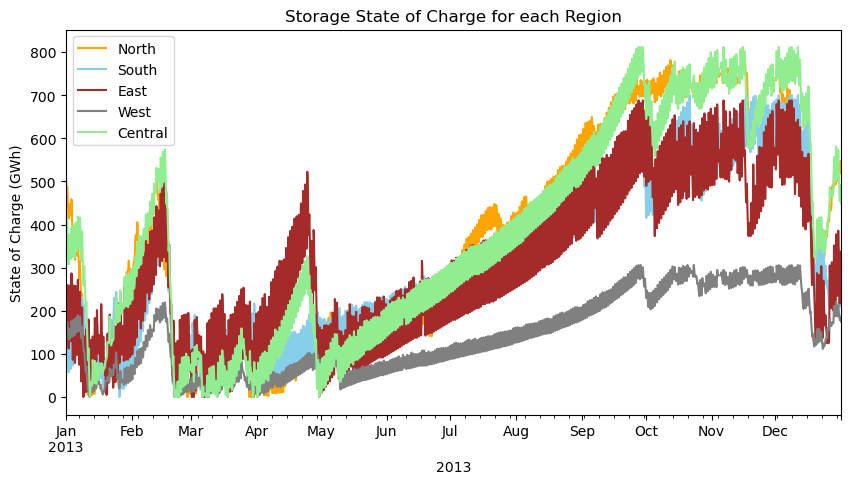

In [90]:
regioncolors = ["orange", "skyblue", "brown","grey", "lightgreen"]
i = 0
test = n2.storage_units_t.state_of_charge.groupby([n2.storage_units.bus], axis=1).sum()

fig, ax = plt.subplots(figsize=(10,5))

for region in region_names:
    x = test[region] / 1e3
    x.plot(color = regioncolors[i], label=region)
    i += 1
    
plt.title('Storage State of Charge for each Region')
plt.legend(loc='upper left')
plt.ylabel('State of Charge (GWh)')
plt.xlabel('2013')
plt.show()

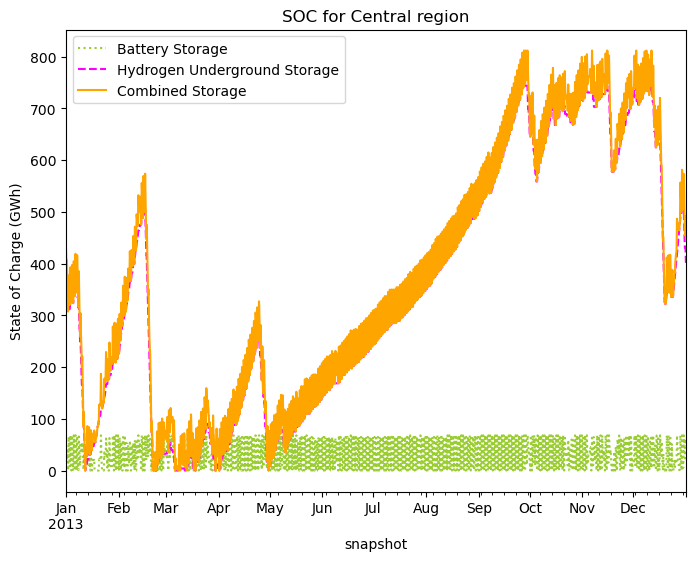

In [91]:
colordict = n.carriers.color.to_dict()
SW_battery = n2.storage_units_t.state_of_charge['battery storage Central'] / 1e3
SW_hydrogen = n2.storage_units_t.state_of_charge['hydrogen storage underground Central'] / 1e3
SW_combined = SW_battery + SW_hydrogen

fig, ax = plt.subplots(figsize=(8, 6))

SW_battery.plot(ax=ax, color=colordict['battery storage'], linestyle=':', label='Battery Storage')
SW_hydrogen.plot(ax=ax, color=colordict['hydrogen storage underground'], linestyle='--', label='Hydrogen Underground Storage')
SW_combined.plot(ax=ax, color='orange', label='Combined Storage')
ax.legend(loc='upper left')
ax.set_title('SOC for Central region')
ax.set_ylabel('State of Charge (GWh)')
plt.show()

In [92]:
demand = n2.snapshot_weightings.generators @ n2.loads_t.p_set.sum(axis=1)
n2_costperMW = system_cost(n2).sum()*1e6 / demand.sum()
print(f'Total system cost is € {round(system_cost(n2).sum()/ 1e3, 2)} Billion @ {round(n2_costperMW,1)} €/MWh')

Total system cost is € 16.86 Billion @ 57.7 €/MWh


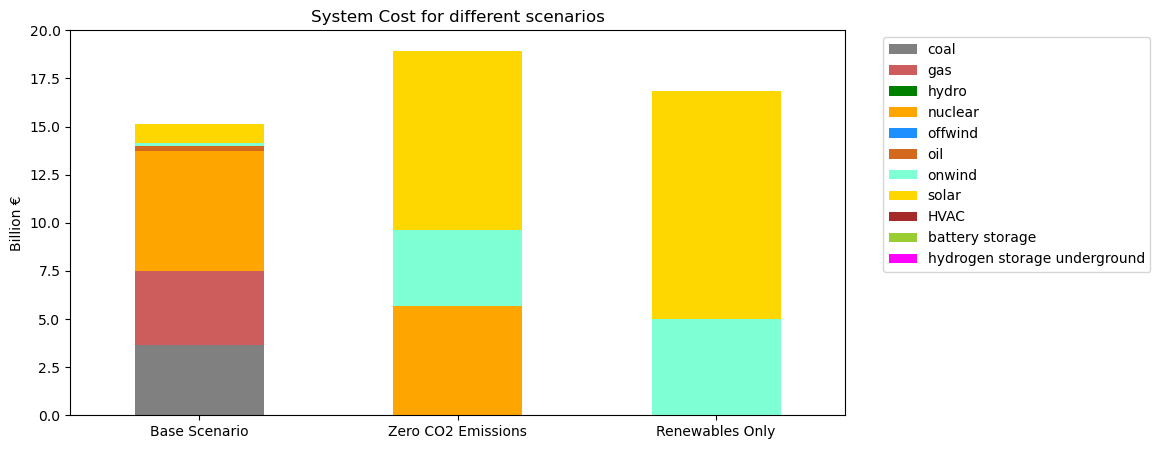

In [93]:
test = system_cost(n)
test1 = system_cost(n1)
test2 = system_cost(n2)

combine_sys_cost = pd.DataFrame()
combine_sys_cost['Base Scenario'] = test / 1e3
combine_sys_cost['Zero CO2 Emissions'] = test1/1e3
combine_sys_cost['Renewables Only'] = test2 / 1e3

combine_sys_cost.T.plot.bar(stacked=True, figsize=(10,5), color=colordict)
plt.title('System Cost for different scenarios')
plt.xticks(rotation=0)
plt.ylabel('Billion €')
plt.ylim(0,20)
plt.legend(loc='best')
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

# 7 Sensitivity Analysis

## 7.1 Variations of Renewable Potentials with no carbon-dioxide emissions

In [94]:
n3 = n1.copy()

In [95]:
dispatch_sensitivity_solar = {}
for solar_potential in [0,25,50,75,100]:
    for i in range(1,6):
        temp_var = n3.generators.loc[f"solar {dict[i]}", "p_nom_max"]
        n3.generators.loc[f"solar {dict[i]}", "p_nom_max"] = solar_potential * n3.generators.loc[f"solar {dict[i]}", "p_nom_max"]
    n3.lopf(solver_name='gurobi')
    dispatch_sensitivity_solar[solar_potential] = n3.generators.groupby("carrier").p_nom_opt.sum()
    for i in range(1,6):
        n3.generators.loc[f"solar {dict[i]}", "p_nom_max"] = temp_var

INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.47s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-82nwungc.lp
Reading time = 1.27 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0xeeec83a9
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 9e+05]
  RHS range        [1e+02, 1e+04]
Presolve removed 195652 rows and 20457 columns
Presolve time: 0.49s
Presolved: 192709 rows, 151853 columns, 557713 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.18s

Barrier statistics:
 Dense cols : 24
 Free vars  : 20438
 AA' NZ     : 5.256e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 6.12e+10
INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.46s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-nw7ox7yr.lp
Reading time = 1.19 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0x715226d3
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 2e+07]
  RHS range        [1e+02, 1e+04]
Presolve removed 188205 rows and 13005 columns
Presolve time: 0.70s
Presolved: 200156 rows, 159305 columns, 580028 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.15s

Barrier statistics:
 Dense cols : 29
 Free vars  : 20440
 AA' NZ     : 5.405e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10
INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 4.13s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


...

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10
INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.39s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-d0uk_9ln.lp
Reading time = 1.17 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0x6e4d902e
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 6e+07]
  RHS range        [1e+02, 1e+04]
Presolve removed 188205 rows and 13005 columns
Presolve time: 0.67s
Presolved: 200156 rows, 159305 columns, 580028 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.12s

Barrier statistics:
 Dense cols : 29
 Free vars  : 20440
 AA' NZ     : 5.405e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10
INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.48s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-tcit02zv.lp
Reading time = 1.12 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0xbb5e8499
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 8e+07]
  RHS range        [1e+02, 1e+04]
Presolve removed 188205 rows and 13005 columns
Presolve time: 0.71s
Presolved: 200156 rows, 159305 columns, 580028 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.13s

Barrier statistics:
 Dense cols : 29
 Free vars  : 20440
 AA' NZ     : 5.405e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10


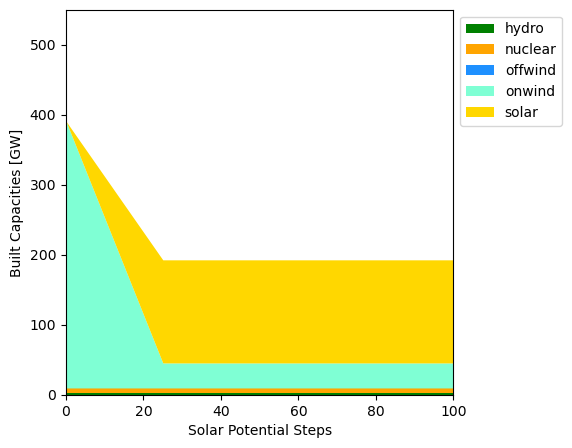

In [96]:
df = pd.DataFrame(dispatch_sensitivity_solar).T.div(1e3) # billion Euro/a
df.plot.area(
    stacked=True,
    linewidth=0,
    color=df.columns.map(n.carriers.color).dropna(),
    figsize=(5,5),
    xlim=(0,100),
    xlabel="Solar Potential Steps",
    ylabel="Built Capacities [GW]",
    ylim=(0,550),
)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")

## 7.2 Varition of technology costs with no carbon-dioxide emissions

In [97]:
cost_sensitivity_solar = {}
for solar_cost in [0, 25, 50, 75, 100]:
    for i in range(1,6):
        temp_var = n3.generators.loc[f"solar {dict[i]}", "p_nom_max"]
        n3.generators.loc[f"solar {dict[i]}", "p_nom_max"] = solar_cost * n3.generators.loc[f"solar {dict[i]}", "p_nom_max"]
    n3.lopf(solver_name='gurobi')
    cost_sensitivity_solar[solar_cost] = system_cost(n3)
    for i in range(1,6):
        n3.generators.loc[f"solar {dict[i]}", "p_nom_max"] = temp_var

INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.7s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-kz_lkabm.lp
Reading time = 1.18 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0xeeec83a9
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 9e+05]
  RHS range        [1e+02, 1e+04]
Presolve removed 195652 rows and 20457 columns
Presolve time: 0.45s
Presolved: 192709 rows, 151853 columns, 557713 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.15s

Barrier statistics:
 Dense cols : 24
 Free vars  : 20438
 AA' NZ     : 5.256e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 6.12e+10
INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.45s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-gndtvedj.lp
Reading time = 1.20 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0x715226d3
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 2e+07]
  RHS range        [1e+02, 1e+04]
Presolve removed 188205 rows and 13005 columns
Presolve time: 0.65s
Presolved: 200156 rows, 159305 columns, 580028 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.13s

Barrier statistics:
 Dense cols : 29
 Free vars  : 20440
 AA' NZ     : 5.405e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10
INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.38s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


...

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10
INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.48s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-c0os32fa.lp
Reading time = 1.21 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0x6e4d902e
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 6e+07]
  RHS range        [1e+02, 1e+04]
Presolve removed 188205 rows and 13005 columns
Presolve time: 0.66s
Presolved: 200156 rows, 159305 columns, 580028 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.13s

Barrier statistics:
 Dense cols : 29
 Free vars  : 20440
 AA' NZ     : 5.405e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10
INFO:pypsa.linopf:Prepare linear problem
INFO:pypsa.linopf:Total preparation time: 2.8s
INFO:pypsa.linopf:Solve linear problem using Gurobi solver


Read LP format model from file C:\Users\SANKET~1\AppData\Local\Temp\pypsa-problem-54imfsf7.lp
Reading time = 1.19 seconds
obj: 388361 rows, 172310 columns, 781236 nonzeros
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 388361 rows, 172310 columns and 781236 nonzeros
Model fingerprint: 0xbb5e8499
Coefficient statistics:
  Matrix range     [1e-06, 3e+02]
  Objective range  [3e-02, 5e+05]
  Bounds range     [4e+03, 8e+07]
  RHS range        [1e+02, 1e+04]
Presolve removed 188205 rows and 13005 columns
Presolve time: 0.67s
Presolved: 200156 rows, 159305 columns, 580028 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.12s

Barrier statistics:
 Dense cols : 29
 Free vars  : 20440
 AA' NZ     : 5.405e+05
 Fa

INFO:pypsa.linopf:Optimization successful. Objective value: 2.56e+10


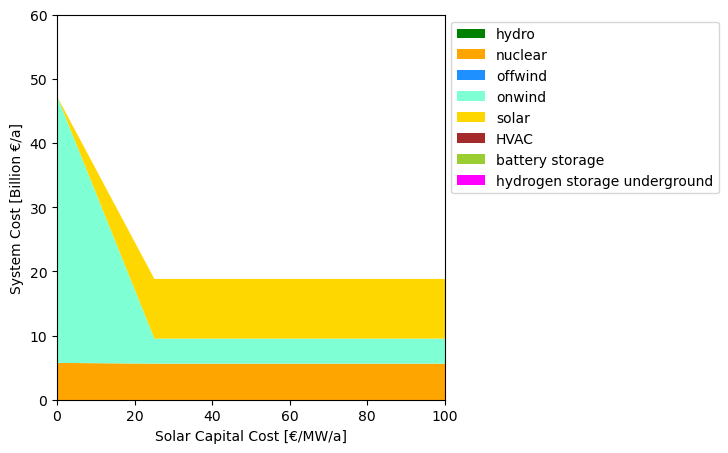

In [98]:
df = pd.DataFrame(cost_sensitivity_solar).T.div(1e3) # billion Euro/a
df.plot.area(
    stacked=True,
    linewidth=0,
    color=df.columns.map(n.carriers.color).dropna(),
    figsize=(5,5),
    xlim=(0,100),
    xlabel="Solar Capital Cost [€/MW/a]",
    ylabel="System Cost [Billion €/a]",
    ylim=(0,60),
)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")